In [1]:
# ============================================================
# PROJECT TITLE
# Predictive Analytics Framework for Advanced Decision Support
# and Business Analytics Applications 3
# ============================================================

print("=" * 75)
print("Predictive Analytics Framework for Advanced Decision Support")
print("and Business Analytics Applications 3")
print("=" * 75)
print("Domain: Predictive Analytics / Business Analytics")
print("Task: Customer Campaign Response Prediction")
print("=" * 75)

Predictive Analytics Framework for Advanced Decision Support
and Business Analytics Applications 3
Domain: Predictive Analytics / Business Analytics
Task: Customer Campaign Response Prediction


In [3]:
from google.colab import files

uploaded = files.upload()

print("Dataset uploaded successfully!")

Saving archive.zip to archive.zip
Dataset uploaded successfully!


In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [7]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("ZIP file extracted successfully!")

print("\nFiles inside the dataset folder:")

for root, dirs, files_list in os.walk('/content/dataset'):
    for file in files_list:
        print(os.path.join(root, file))

Saving archive.zip to archive (1).zip
ZIP file extracted successfully!

Files inside the dataset folder:
/content/dataset/marketing_campaign.csv


In [8]:
import pandas as pd

file_path = "/content/dataset/marketing_campaign.csv"

df = pd.read_csv(file_path, sep="\t")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [11]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(2240, 29)

Column Names:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 

In [12]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,11.984069,1893.0,1959.0,1970.0,1977.0,1996.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.0,666666.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Dt_Customer,2240,663,31-08-2012,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2240.0,NaN,NaN,NaN,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0


In [13]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values
})

missing_table = missing_table[missing_table["Missing Values"] > 0]

print("Columns containing missing values:")
display(missing_table)

Columns containing missing values:


,Column,Missing Values
4,Income,24


In [14]:
duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


In [15]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:")
print(df.shape)

Dataset shape after removing duplicates:
(2240, 29)


In [16]:
print("Response value counts:")
print(df["Response"].value_counts())

print("\nResponse percentages:")
print(df["Response"].value_counts(normalize=True) * 100)

Response value counts:
Response
0    1906
1     334
Name: count, dtype: int64

Response percentages:
Response
0    85.089286
1    14.910714
Name: proportion, dtype: float64


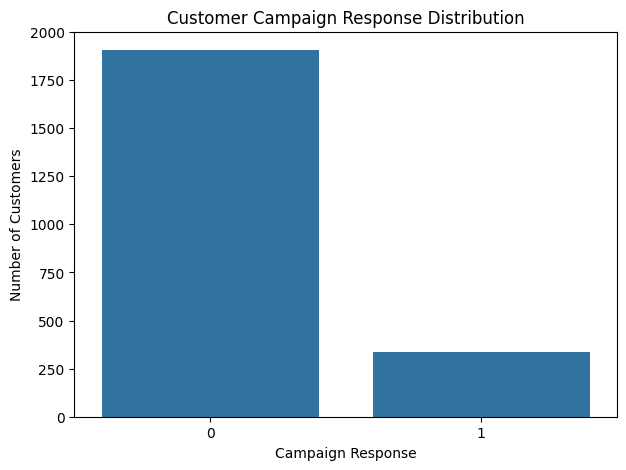

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Response")

plt.title("Customer Campaign Response Distribution")
plt.xlabel("Campaign Response")
plt.ylabel("Number of Customers")

plt.show()

In [18]:
# Convert Dt_Customer into datetime
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True,
    errors="coerce"
)

# Fill missing Income values using median
if "Income" in df.columns:
    df["Income"] = df["Income"].fillna(df["Income"].median())

print("Data cleaning completed.")

Data cleaning completed.


In [19]:
# Customer age
df["Age"] = 2024 - df["Year_Birth"]

# Total children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# Total purchases
df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

# Total spending
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

# Total campaign acceptances
campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

df["Total_Campaign_Accepted"] = df[campaign_columns].sum(axis=1)

print("Feature engineering completed.")

Feature engineering completed.


In [20]:
new_features = [
    "Age",
    "Total_Children",
    "Total_Purchases",
    "Total_Spending",
    "Total_Campaign_Accepted"
]

df[new_features].head()

,Age,Total_Children,Total_Purchases,Total_Spending,Total_Campaign_Accepted
0,67,0,22,1617,0
1,70,2,4,27,0
2,59,0,20,776,0
3,40,1,6,53,0
4,43,1,14,422,0


In [21]:
df = df[
    (df["Age"] >= 18) &
    (df["Age"] <= 100)
].copy()

print("Dataset shape after age filtering:")
print(df.shape)

Dataset shape after age filtering:
(2237, 34)


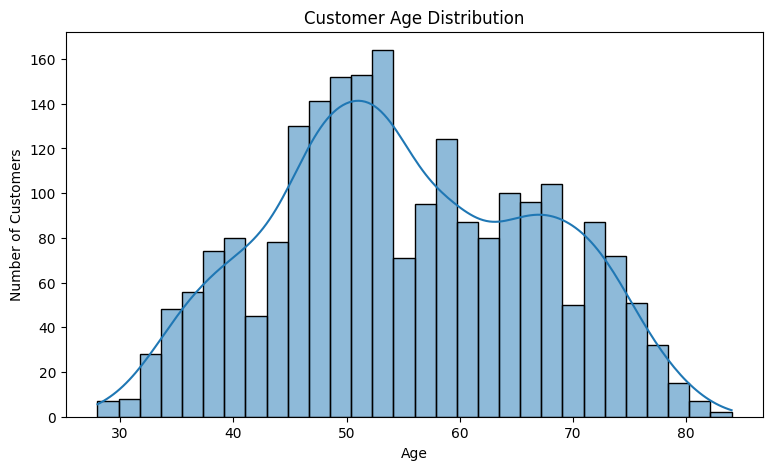

In [22]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

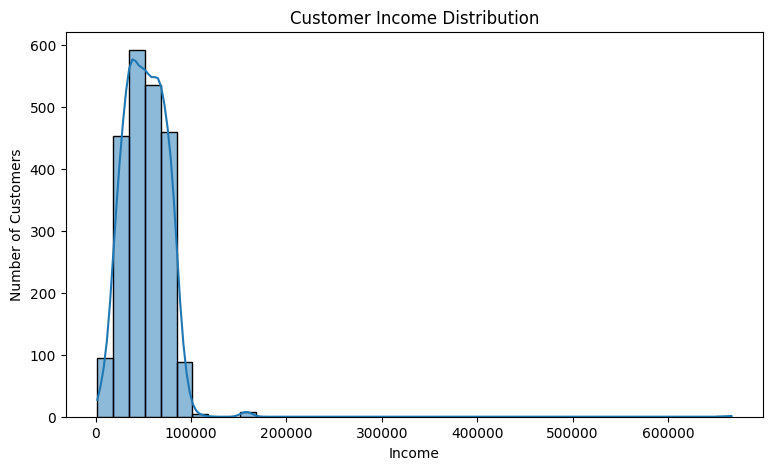

In [23]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["Income"],
    bins=40,
    kde=True
)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

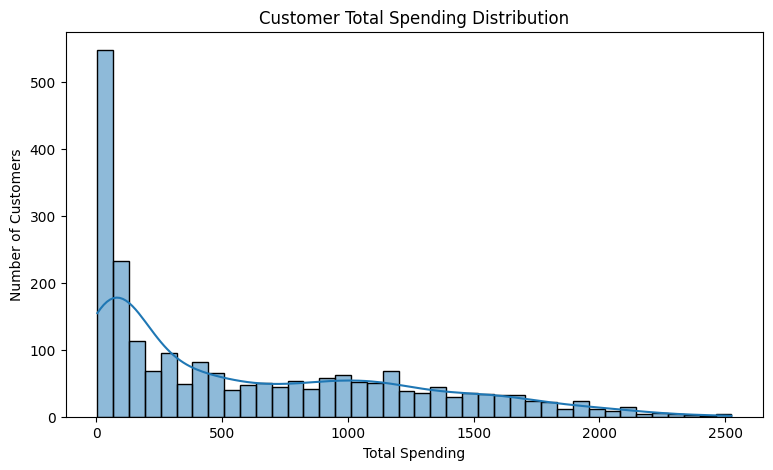

In [24]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["Total_Spending"],
    bins=40,
    kde=True
)

plt.title("Customer Total Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

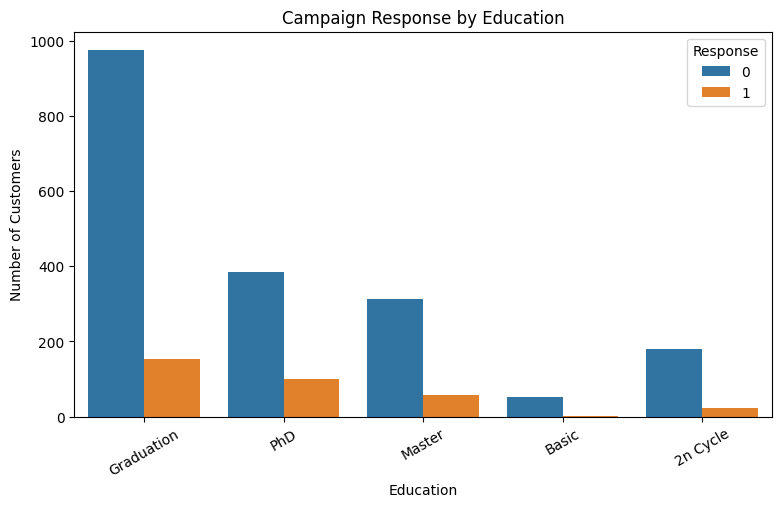

In [25]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Education",
    hue="Response"
)

plt.title("Campaign Response by Education")
plt.xlabel("Education")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

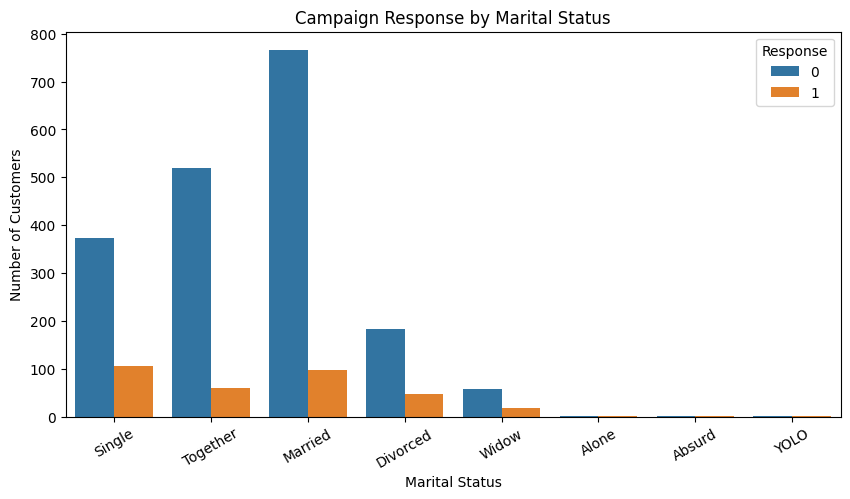

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Marital_Status",
    hue="Response"
)

plt.title("Campaign Response by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

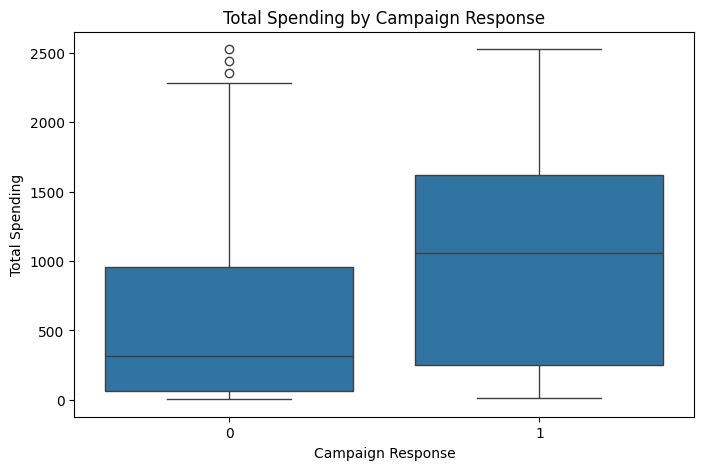

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Response",
    y="Total_Spending"
)

plt.title("Total Spending by Campaign Response")
plt.xlabel("Campaign Response")
plt.ylabel("Total Spending")

plt.show()

In [28]:
channel_data = pd.DataFrame({
    "Channel": [
        "Web",
        "Catalog",
        "Store"
    ],
    "Purchases": [
        df["NumWebPurchases"].sum(),
        df["NumCatalogPurchases"].sum(),
        df["NumStorePurchases"].sum()
    ]
})

channel_data

,Channel,Purchases
0,Web,9143
1,Catalog,5956
2,Store,12962


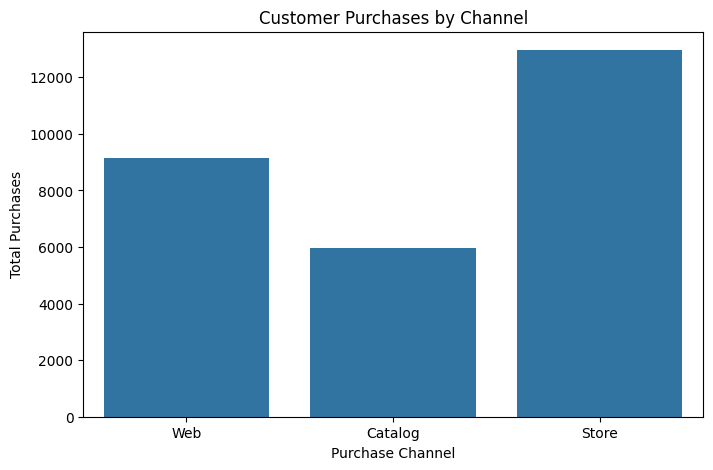

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=channel_data,
    x="Channel",
    y="Purchases"
)

plt.title("Customer Purchases by Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Total Purchases")

plt.show()

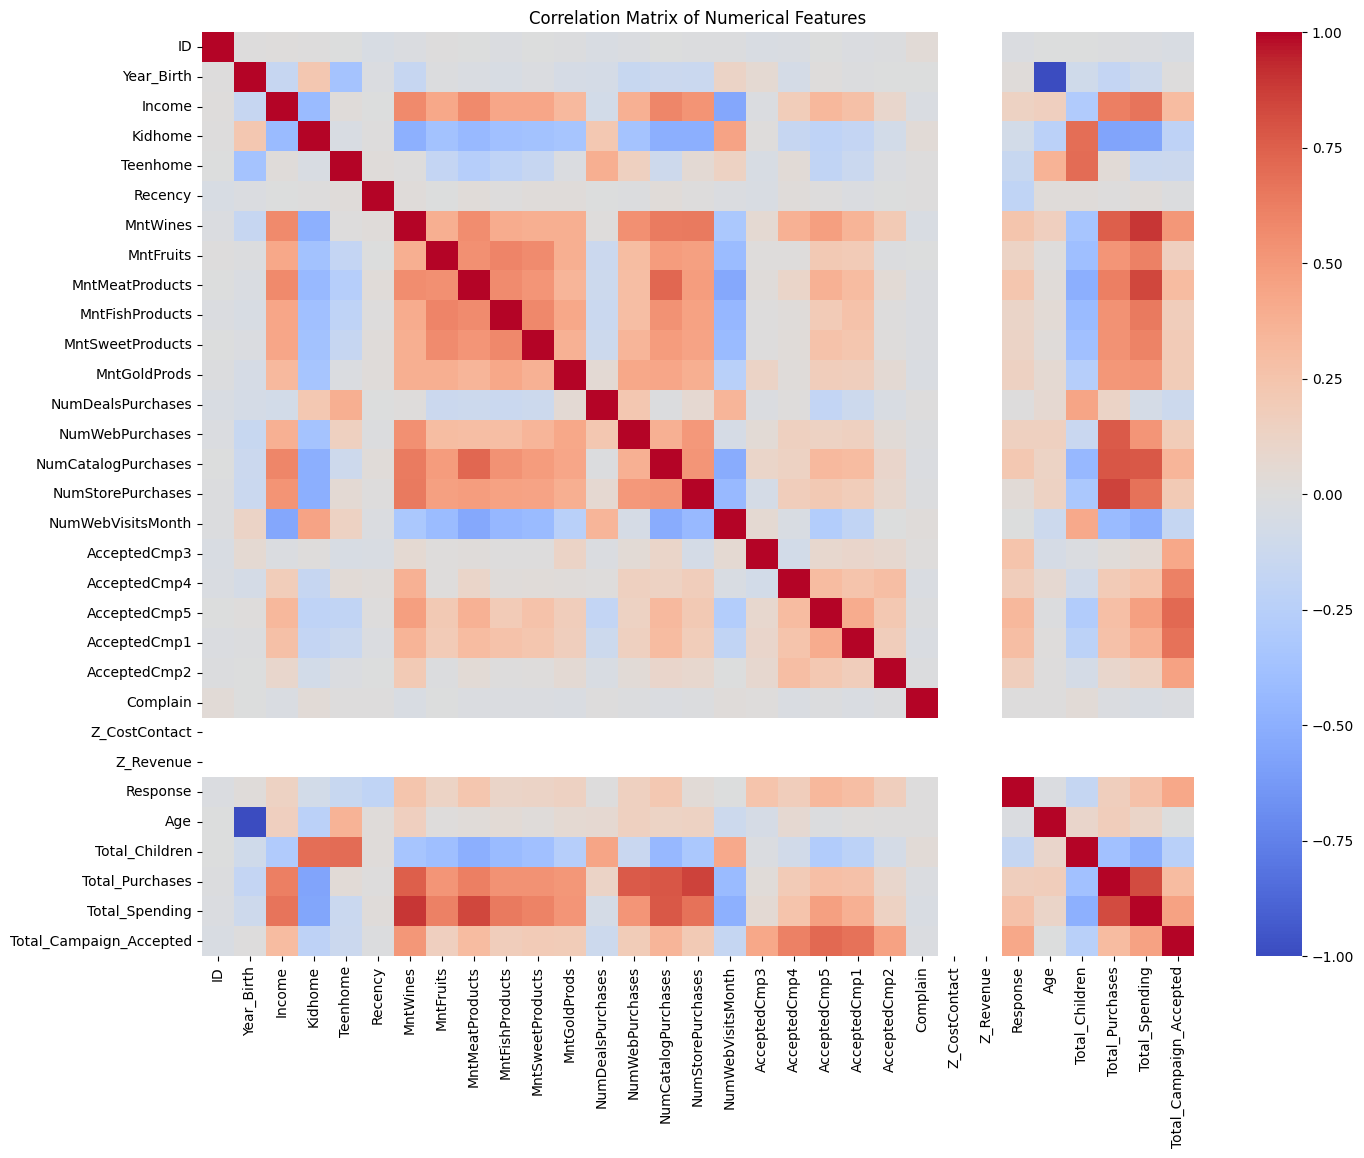

In [30]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [31]:
# Make a copy
model_df = df.copy()

# Remove columns that are not directly useful for prediction
columns_to_drop = [
    "ID",
    "Dt_Customer",
    "Z_CostContact",
    "Z_Revenue",
    "Response"
]

X = model_df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

y = model_df["Response"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Features:
['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Age', 'Total_Children', 'Total_Purchases', 'Total_Spending', 'Total_Campaign_Accepted']

Target:
Response

Feature matrix shape: (2237, 29)
Target shape: (2237,)


In [32]:
# Convert categorical variables to numerical dummy variables
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Feature matrix after encoding:")
print(X.shape)

Feature matrix after encoding:
(2237, 38)


In [33]:
# Replace infinite values
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing numerical values with median
X = X.fillna(X.median(numeric_only=True))

# Any remaining missing values
X = X.fillna(0)

print("Remaining missing values:", X.isnull().sum().sum())

Remaining missing values: 0


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1789, 38)
Testing data: (448, 38)


In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [36]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_predictions = logistic_model.predict(X_test_scaled)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [37]:
decision_tree = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

dt_predictions = decision_tree.predict(X_test)

dt_probabilities = decision_tree.predict_proba(
    X_test
)[:, 1]

print("Decision Tree training completed.")

Decision Tree training completed.


In [38]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(X_test)

rf_probabilities = random_forest.predict_proba(
    X_test
)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


In [39]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(
    X_train,
    y_train
)

gb_predictions = gradient_boosting.predict(X_test)

gb_probabilities = gradient_boosting.predict_proba(
    X_test
)[:, 1]

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [40]:
!pip install -q xgboost

In [3]:
# ============================================================
# COMPLETE DATASET SETUP + TRAIN/TEST SPLIT
# Run this cell from the beginning if df is not defined
# ============================================================

from google.colab import files
import zipfile
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Upload ZIP file
# ------------------------------------------------------------

print("Please select your archive.zip file...")

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

# ------------------------------------------------------------
# 2. Extract ZIP
# ------------------------------------------------------------

extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("\nZIP extracted successfully.")

# ------------------------------------------------------------
# 3. Find marketing_campaign.csv
# ------------------------------------------------------------

csv_path = None

for root, dirs, files_list in os.walk(extract_path):
    for file in files_list:
        if file.lower() == "marketing_campaign.csv":
            csv_path = os.path.join(root, file)

if csv_path is None:
    raise FileNotFoundError(
        "marketing_campaign.csv was not found inside the ZIP file."
    )

print("CSV found at:")
print(csv_path)

# ------------------------------------------------------------
# 4. Load dataset
# ------------------------------------------------------------

df = pd.read_csv(
    csv_path,
    sep="\t"
)

print("\nDataset loaded successfully!")
print("Original shape:", df.shape)

# ------------------------------------------------------------
# 5. Remove duplicate records
# ------------------------------------------------------------

df = df.drop_duplicates()

# ------------------------------------------------------------
# 6. Convert customer date
# ------------------------------------------------------------

df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True,
    errors="coerce"
)

# ------------------------------------------------------------
# 7. Handle missing Income
# ------------------------------------------------------------

df["Income"] = df["Income"].fillna(
    df["Income"].median()
)

# ------------------------------------------------------------
# 8. Feature Engineering
# ------------------------------------------------------------

# Customer age
df["Age"] = 2024 - df["Year_Birth"]

# Number of children
df["Total_Children"] = (
    df["Kidhome"] +
    df["Teenhome"]
)

# Total purchases
df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

# Total spending
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

# Total previous campaign acceptances
campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

df["Total_Campaign_Accepted"] = (
    df[campaign_columns].sum(axis=1)
)

# ------------------------------------------------------------
# 9. Remove unrealistic ages
# ------------------------------------------------------------

df = df[
    (df["Age"] >= 18) &
    (df["Age"] <= 100)
].copy()

# ------------------------------------------------------------
# 10. Create X and y
# ------------------------------------------------------------

columns_to_drop = [
    "ID",
    "Dt_Customer",
    "Z_CostContact",
    "Z_Revenue",
    "Response"
]

X = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

y = df["Response"]

# ------------------------------------------------------------
# 11. Convert categorical variables
# ------------------------------------------------------------

X = pd.get_dummies(
    X,
    drop_first=True
)

# ------------------------------------------------------------
# 12. Handle infinite/missing values
# ------------------------------------------------------------

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median(numeric_only=True)
)

X = X.fillna(0)

# ------------------------------------------------------------
# 13. Train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 14. Feature scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 15. Display final information
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATA PREPARATION COMPLETED")
print("=" * 60)

print("Dataset shape:", df.shape)
print("Number of features:", X.shape[1])

print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nEverything is ready for model training!")

Please select your archive.zip file...


Saving archive.zip to archive.zip

ZIP extracted successfully.
CSV found at:
/content/dataset/marketing_campaign.csv

Dataset loaded successfully!
Original shape: (2240, 29)

DATA PREPARATION COMPLETED
Dataset shape: (2237, 34)
Number of features: 38

Training data:
X_train: (1789, 38)
y_train: (1789,)

Testing data:
X_test: (448, 38)
y_test: (448,)

Target distribution:
Response
0    1903
1     334
Name: count, dtype: int64

Target percentages:
Response
0    85.07
1    14.93
Name: proportion, dtype: float64

Everything is ready for model training!


In [4]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_predictions = logistic_model.predict(X_test_scaled)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Logistic Regression completed.")

Logistic Regression completed.


In [5]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

dt_predictions = decision_tree.predict(X_test)

dt_probabilities = decision_tree.predict_proba(
    X_test
)[:, 1]

print("Decision Tree completed.")

Decision Tree completed.


In [6]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(X_test)

rf_probabilities = random_forest.predict_proba(
    X_test
)[:, 1]

print("Random Forest completed.")

Random Forest completed.


In [7]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(
    X_train,
    y_train
)

gb_predictions = gradient_boosting.predict(X_test)

gb_probabilities = gradient_boosting.predict_proba(
    X_test
)[:, 1]

print("Gradient Boosting completed.")

Gradient Boosting completed.


In [8]:
!pip install -q xgboost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(X_test)

xgb_probabilities = xgb_model.predict_proba(
    X_test
)[:, 1]

print("XGBoost completed successfully.")

XGBoost completed successfully.


In [9]:
def evaluate_model(model_name, y_true, predictions, probabilities):

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        probabilities
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

In [11]:
# ============================================================
# MODEL EVALUATION IMPORTS + FUNCTION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities
):

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        probabilities
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

print("Evaluation functions loaded successfully!")

Evaluation functions loaded successfully!


In [12]:
# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_predictions,
        dt_probabilities
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_predictions,
        gb_probabilities
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_predictions,
        xgb_probabilities
    )
)

results_df = pd.DataFrame(results)

print("Model comparison completed!")

display(results_df)

Model comparison completed!


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.888393,0.717949,0.417910,0.528302,0.887100
1,Decision Tree,0.841518,0.462963,0.373134,0.413223,0.665746
2,Random Forest,0.877232,0.700000,0.313433,0.432990,0.869315
3,Gradient Boosting,0.881696,0.718750,0.343284,0.464646,0.893760
4,XGBoost,0.875000,0.641026,0.373134,0.471698,0.891840


In [13]:
results_percentage = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

for column in metric_columns:
    results_percentage[column] = (
        results_percentage[column] * 100
    ).round(2)

display(results_percentage)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,88.84,71.79,41.79,52.83,88.71
1,Decision Tree,84.15,46.30,37.31,41.32,66.57
2,Random Forest,87.72,70.00,31.34,43.30,86.93
3,Gradient Boosting,88.17,71.88,34.33,46.46,89.38
4,XGBoost,87.50,64.10,37.31,47.17,89.18


In [16]:
# ============================================================
# GRAPHING LIBRARIES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("Graphing libraries loaded successfully!")

Graphing libraries loaded successfully!


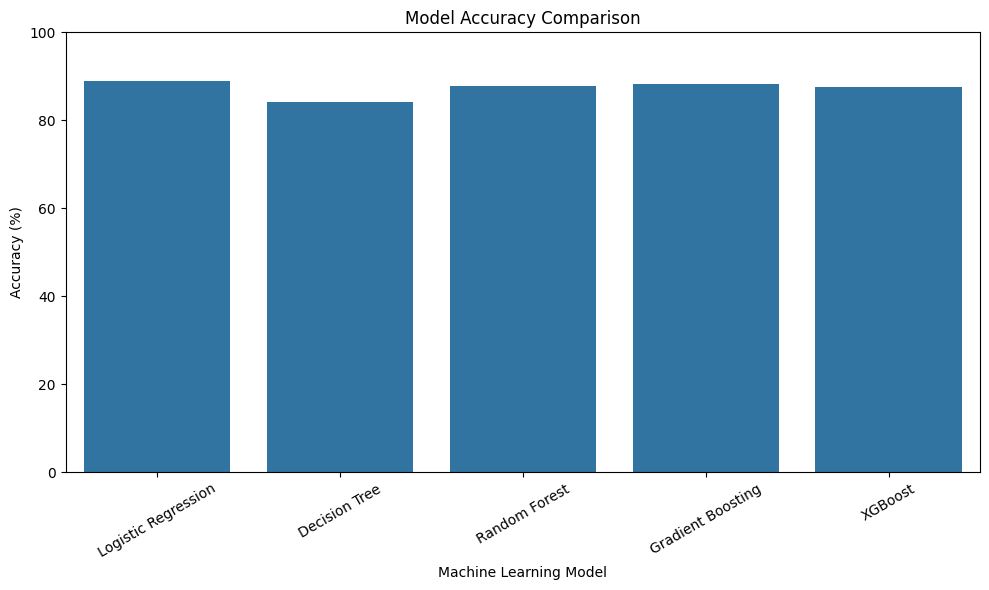

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_percentage,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=30)

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

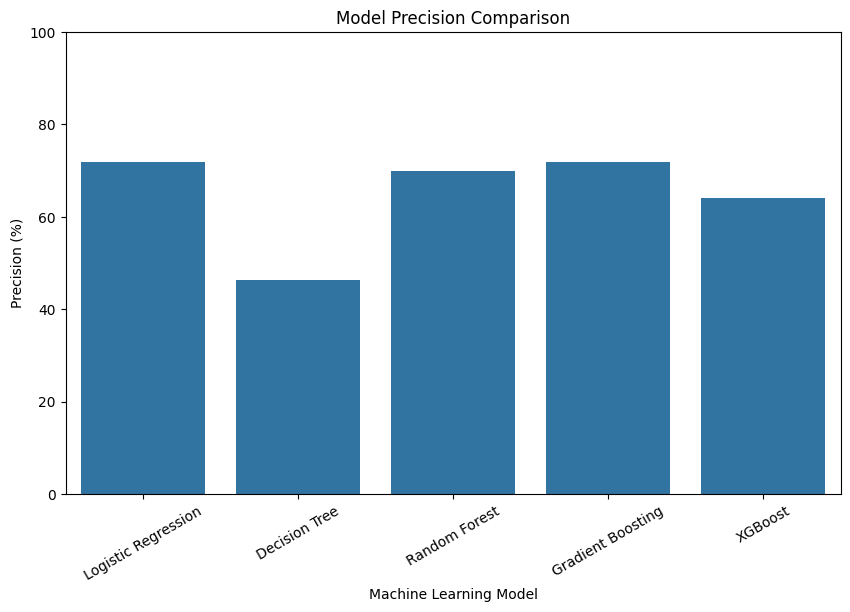

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_percentage,
    x="Model",
    y="Precision"
)

plt.title("Model Precision Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Precision (%)")

plt.xticks(rotation=30)

plt.ylim(0, 100)

plt.show()

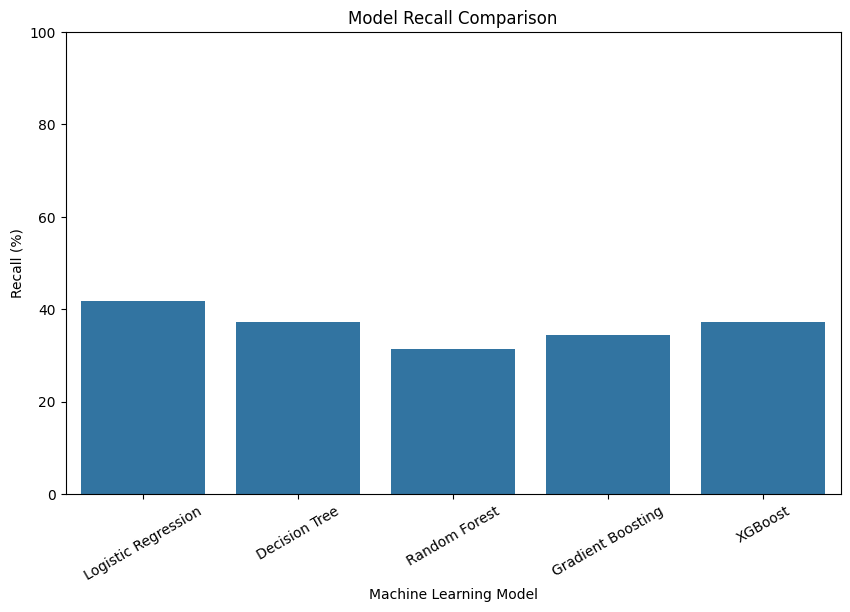

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_percentage,
    x="Model",
    y="Recall"
)

plt.title("Model Recall Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Recall (%)")

plt.xticks(rotation=30)

plt.ylim(0, 100)

plt.show()

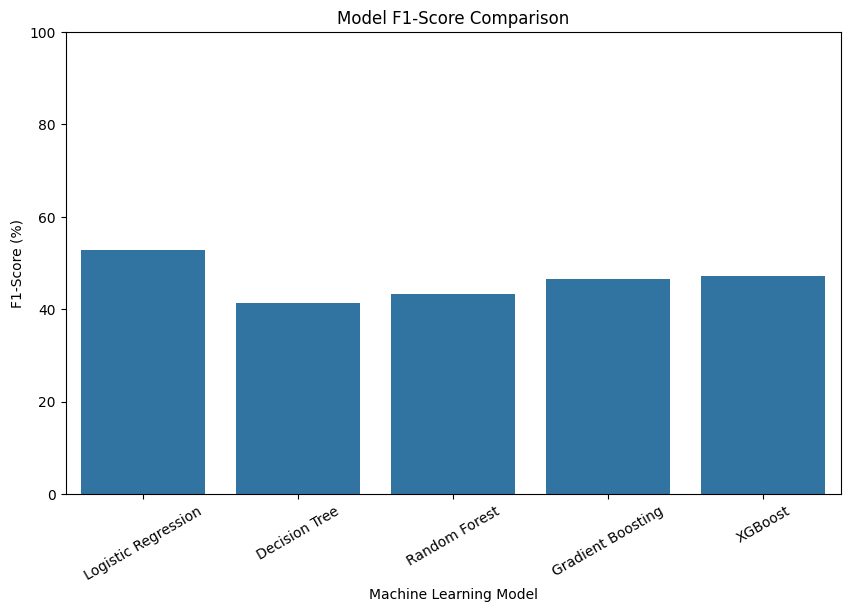

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_percentage,
    x="Model",
    y="F1-Score"
)

plt.title("Model F1-Score Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("F1-Score (%)")

plt.xticks(rotation=30)

plt.ylim(0, 100)

plt.show()

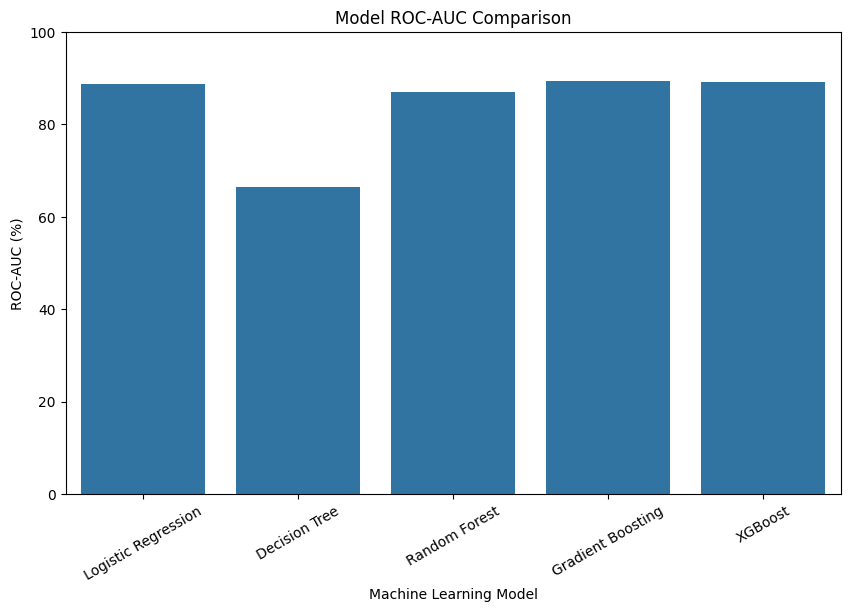

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_percentage,
    x="Model",
    y="ROC-AUC"
)

plt.title("Model ROC-AUC Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("ROC-AUC (%)")

plt.xticks(rotation=30)

plt.ylim(0, 100)

plt.show()

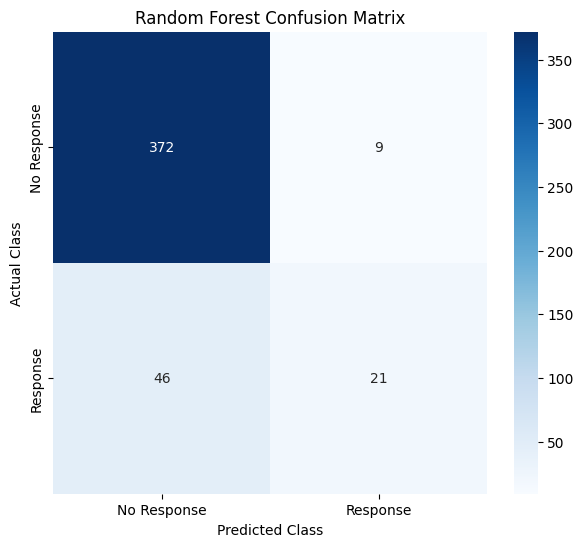

In [22]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Response", "Response"],
    yticklabels=["No Response", "Response"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [23]:
print("Random Forest Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "No Response",
            "Response"
        ]
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

 No Response       0.89      0.98      0.93       381
    Response       0.70      0.31      0.43        67

    accuracy                           0.88       448
   macro avg       0.79      0.64      0.68       448
weighted avg       0.86      0.88      0.86       448



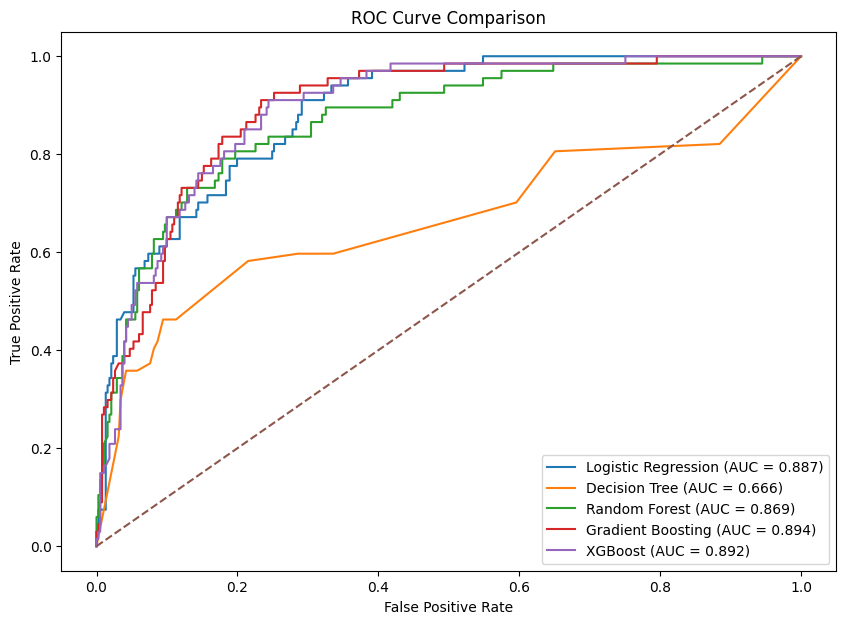

In [24]:
models_probabilities = {
    "Logistic Regression": logistic_probabilities,
    "Decision Tree": dt_probabilities,
    "Random Forest": rf_probabilities,
    "Gradient Boosting": gb_probabilities,
    "XGBoost": xgb_probabilities
}

plt.figure(figsize=(10,7))

for model_name, probabilities in models_probabilities.items():

    fpr, tpr, thresholds = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [25]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
4,Recency,0.091518
26,Total_Campaign_Accepted,0.078648
1,Income,0.065945
25,Total_Spending,0.056714
5,MntWines,0.056480
7,MntMeatProducts,0.054930
10,MntGoldProds,0.047755
6,MntFruits,0.037986
15,NumWebVisitsMonth,0.037719
14,NumStorePurchases,0.036553


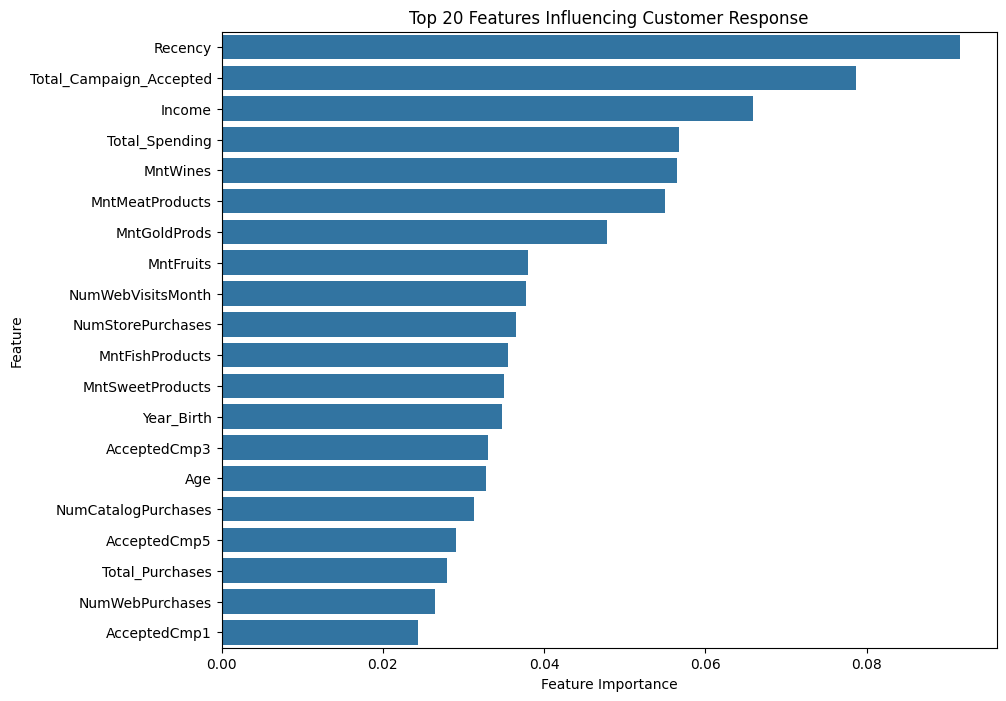

In [26]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Features Influencing Customer Response")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [27]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(20)

,Feature,Importance
26,Total_Campaign_Accepted,0.161556
17,AcceptedCmp4,0.051714
3,Teenhome,0.036662
4,Recency,0.036229
15,NumWebVisitsMonth,0.034656
35,Marital_Status_Together,0.031006
14,NumStorePurchases,0.030289
30,Education_PhD,0.029868
34,Marital_Status_Single,0.029248
13,NumCatalogPurchases,0.027710


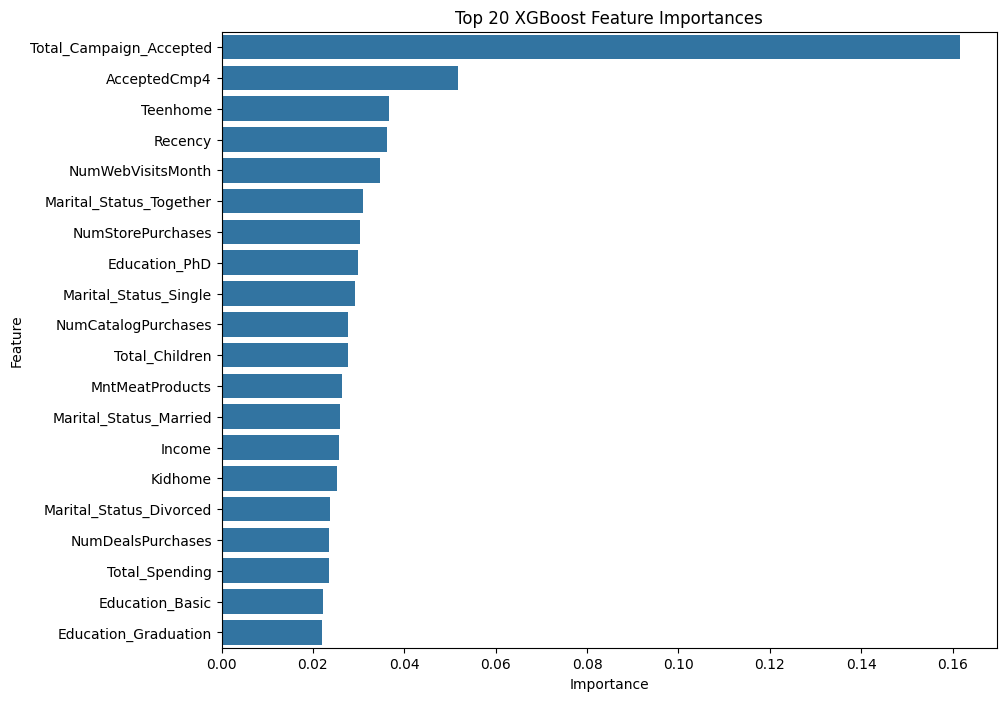

In [28]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=xgb_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [29]:
best_model_row = results_df.loc[
    results_df["ROC-AUC"].idxmax()
]

print("Model with highest ROC-AUC:")
print(best_model_row["Model"])

print("\nPerformance:")
print(best_model_row)

Model with highest ROC-AUC:
Gradient Boosting

Performance:
Model        Gradient Boosting
Accuracy              0.881696
Precision              0.71875
Recall                0.343284
F1-Score              0.464646
ROC-AUC                0.89376
Name: 3, dtype: object


In [30]:
prediction_data = X_test.copy()

prediction_data["Actual_Response"] = y_test.values

prediction_data["Predicted_Response"] = rf_predictions

prediction_data["Response_Probability"] = rf_probabilities

prediction_data.head(10)

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Actual_Response,Predicted_Response,Response_Probability
1518,1972,37787.0,1,0,50,40,1,40,4,3,...,False,False,True,False,False,False,False,0,0,0.062197
178,1959,38285.0,2,1,96,2,0,5,2,0,...,False,False,False,False,True,False,False,0,0,0.018154
235,1975,22212.0,1,0,49,5,9,20,6,8,...,False,False,True,False,False,False,False,0,0,0.068531
1429,1972,31907.0,0,0,75,33,87,64,175,16,...,False,False,False,True,False,False,False,0,0,0.129827
1327,1975,45503.0,1,0,54,97,4,44,6,1,...,False,False,True,False,False,False,False,0,0,0.052605
2017,1967,27943.0,1,1,89,12,1,16,4,1,...,False,False,False,False,True,False,False,0,0,0.010873
1012,1978,30168.0,1,0,51,154,20,66,0,12,...,False,False,False,True,False,False,False,0,0,0.247352
1296,1978,34043.0,1,0,97,20,2,14,3,0,...,False,False,False,False,True,False,False,0,0,0.043979
1479,1961,57072.0,0,1,79,944,0,60,0,0,...,False,False,True,False,False,False,False,0,0,0.235437
2135,1965,58692.0,0,1,21,301,11,61,4,7,...,False,False,True,False,False,False,False,0,0,0.022680


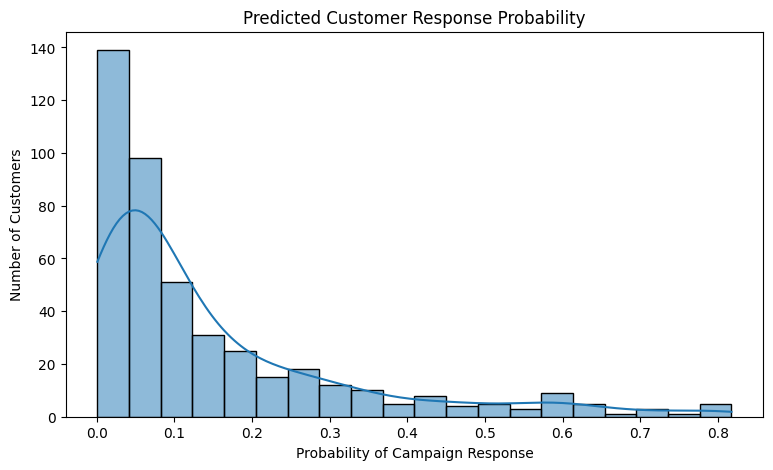

In [31]:
plt.figure(figsize=(9,5))

sns.histplot(
    prediction_data["Response_Probability"],
    bins=20,
    kde=True
)

plt.title("Predicted Customer Response Probability")
plt.xlabel("Probability of Campaign Response")
plt.ylabel("Number of Customers")

plt.show()

In [32]:
def customer_segment(probability):

    if probability >= 0.70:
        return "High Probability"

    elif probability >= 0.40:
        return "Medium Probability"

    else:
        return "Low Probability"


prediction_data["Customer_Segment"] = (
    prediction_data["Response_Probability"]
    .apply(customer_segment)
)

prediction_data[
    [
        "Actual_Response",
        "Predicted_Response",
        "Response_Probability",
        "Customer_Segment"
    ]
].head(20)

,Actual_Response,Predicted_Response,Response_Probability,Customer_Segment
1518,0,0,0.062197,Low Probability
178,0,0,0.018154,Low Probability
235,0,0,0.068531,Low Probability
1429,0,0,0.129827,Low Probability
1327,0,0,0.052605,Low Probability
2017,0,0,0.010873,Low Probability
1012,0,0,0.247352,Low Probability
1296,0,0,0.043979,Low Probability
1479,0,0,0.235437,Low Probability
2135,0,0,0.022680,Low Probability


In [33]:
segment_counts = (
    prediction_data["Customer_Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "Customer Segment",
    "Number of Customers"
]

segment_counts

,Customer Segment,Number of Customers
0,Low Probability,404
1,Medium Probability,35
2,High Probability,9


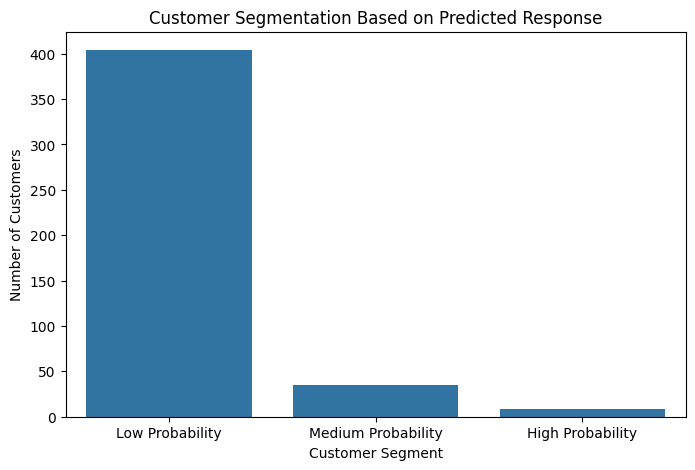

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_counts,
    x="Customer Segment",
    y="Number of Customers"
)

plt.title("Customer Segmentation Based on Predicted Response")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

In [35]:
# Select one existing customer from test data
sample_customer = X_test.iloc[[0]]

prediction = random_forest.predict(
    sample_customer
)[0]

probability = random_forest.predict_proba(
    sample_customer
)[0][1]

print("=" * 60)
print("CUSTOMER CAMPAIGN RESPONSE PREDICTION")
print("=" * 60)

print("Predicted Response:", prediction)
print(f"Response Probability: {probability:.2%}")

if probability >= 0.70:
    print("Decision Support Recommendation: High-priority customer")

elif probability >= 0.40:
    print("Decision Support Recommendation: Medium-priority customer")

else:
    print("Decision Support Recommendation: Low-priority customer")

CUSTOMER CAMPAIGN RESPONSE PREDICTION
Predicted Response: 0
Response Probability: 6.22%
Decision Support Recommendation: Low-priority customer


In [36]:
sample_customers = X_test.iloc[:20].copy()

sample_predictions = random_forest.predict(
    sample_customers
)

sample_probabilities = random_forest.predict_proba(
    sample_customers
)[:, 1]

final_predictions = sample_customers.copy()

final_predictions["Predicted_Response"] = sample_predictions

final_predictions["Response_Probability"] = (
    sample_probabilities
)

final_predictions["Customer_Segment"] = [
    customer_segment(p)
    for p in sample_probabilities
]

final_predictions[
    [
        "Predicted_Response",
        "Response_Probability",
        "Customer_Segment"
    ]
]

,Predicted_Response,Response_Probability,Customer_Segment
1518,0,0.062197,Low Probability
178,0,0.018154,Low Probability
235,0,0.068531,Low Probability
1429,0,0.129827,Low Probability
1327,0,0.052605,Low Probability
2017,0,0.010873,Low Probability
1012,0,0.247352,Low Probability
1296,0,0.043979,Low Probability
1479,0,0.235437,Low Probability
2135,0,0.022680,Low Probability


In [37]:
high_priority_customers = final_predictions[
    final_predictions["Customer_Segment"] == "High Probability"
]

print(
    "Number of high-probability customers:",
    len(high_priority_customers)
)

high_priority_customers[
    [
        "Predicted_Response",
        "Response_Probability",
        "Customer_Segment"
    ]
]

Number of high-probability customers: 0


,Predicted_Response,Response_Probability,Customer_Segment


In [38]:
print("=" * 70)
print("BUSINESS DECISION SUPPORT SUMMARY")
print("=" * 70)

print("""
1. Predictive analytics is used to estimate customer campaign response.

2. Multiple machine learning algorithms are trained and evaluated.

3. Accuracy, Precision, Recall, F1-Score and ROC-AUC are used
   to evaluate model performance.

4. Customer response probability is generated by the predictive model.

5. Customers are categorized into High, Medium and Low probability
   groups for decision-support purposes.

6. The framework can help organizations prioritize customers,
   analyze campaign response patterns and support targeted
   marketing decisions.
""")

BUSINESS DECISION SUPPORT SUMMARY

1. Predictive analytics is used to estimate customer campaign response.

2. Multiple machine learning algorithms are trained and evaluated.

3. Accuracy, Precision, Recall, F1-Score and ROC-AUC are used
   to evaluate model performance.

4. Customer response probability is generated by the predictive model.

5. Customers are categorized into High, Medium and Low probability
   groups for decision-support purposes.

6. The framework can help organizations prioritize customers,
   analyze campaign response patterns and support targeted
   marketing decisions.



In [39]:
final_table = results_percentage.copy()

final_table = final_table.sort_values(
    by="ROC-AUC",
    ascending=False
)

print("FINAL MODEL PERFORMANCE COMPARISON")

display(final_table)

FINAL MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Gradient Boosting,88.17,71.88,34.33,46.46,89.38
4,XGBoost,87.50,64.10,37.31,47.17,89.18
0,Logistic Regression,88.84,71.79,41.79,52.83,88.71
2,Random Forest,87.72,70.00,31.34,43.30,86.93
1,Decision Tree,84.15,46.30,37.31,41.32,66.57


In [40]:
final_table.to_csv(
    "model_performance_results.csv",
    index=False
)

prediction_data.to_csv(
    "customer_predictions.csv",
    index=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [41]:
print("=" * 80)
print("PROJECT COMPLETED")
print("=" * 80)

print("Project: Predictive Analytics Framework for Advanced Decision Support")
print("         and Business Analytics Applications 3")
print()
print("Dataset: Marketing Campaign Customer Data")
print("Prediction Target: Campaign Response")
print()
print("Models implemented:")
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")
print("4. Gradient Boosting")
print("5. XGBoost")
print()
print("Evaluation metrics:")
print("Accuracy | Precision | Recall | F1-Score | ROC-AUC")
print()
print("Decision-support component:")
print("Customer response probability and customer prioritization")
print("=" * 80)

PROJECT COMPLETED
Project: Predictive Analytics Framework for Advanced Decision Support
         and Business Analytics Applications 3

Dataset: Marketing Campaign Customer Data
Prediction Target: Campaign Response

Models implemented:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost

Evaluation metrics:
Accuracy | Precision | Recall | F1-Score | ROC-AUC

Decision-support component:
Customer response probability and customer prioritization


In [42]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================

!pip install -q xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [43]:
# ============================================================
# CELL 2: CHECK DATA
# ============================================================

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training shape: (1789, 38)
Testing shape : (448, 38)

Training target distribution:
Response
0    1522
1     267
Name: count, dtype: int64

Testing target distribution:
Response
0    381
1     67
Name: count, dtype: int64


In [46]:
# ============================================================
# FAST RANDOM FOREST TUNING
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_params = {
    "n_estimators": [150, 250, 350],
    "max_depth": [8, 12, 16],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=8,              # only 8 combinations instead of 30
    scoring="roc_auc",
    cv=3,                  # 3 folds instead of 5
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("Random Forest tuning completed!")
print("\nBest parameters:")
print(rf_search.best_params_)
print("\nBest CV ROC-AUC:")
print(round(rf_search.best_score_ * 100, 2), "%")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Random Forest tuning completed!

Best parameters:
{'n_estimators': 350, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 16}

Best CV ROC-AUC:
87.06 %


In [47]:
# ============================================================
# FAST XGBOOST TUNING
# ============================================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    "n_estimators": [150, 250, 350],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("XGBoost tuning completed!")
print("\nBest parameters:")
print(xgb_search.best_params_)
print("\nBest CV ROC-AUC:")
print(round(xgb_search.best_score_ * 100, 2), "%")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
XGBoost tuning completed!

Best parameters:
{'subsample': 0.8, 'n_estimators': 350, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.9}

Best CV ROC-AUC:
87.81 %


In [49]:
# ============================================================
# FAST GRADIENT BOOSTING
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier

best_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

best_gb.fit(X_train, y_train)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [50]:
# ============================================================
# FAST RANDOM FOREST
# ============================================================

best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

print("Random Forest completed!")

Random Forest completed!


In [51]:
# ============================================================
# FAST XGBOOST
# ============================================================

best_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

print("XGBoost completed!")

XGBoost completed!


In [52]:
# ============================================================
# EXTRA TREES
# ============================================================

extra_trees = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

extra_trees.fit(X_train, y_train)

print("Extra Trees completed!")

Extra Trees completed!


In [53]:
# ============================================================
# FINAL FAST MODEL COMPARISON
# ============================================================

models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "Gradient Boosting": best_gb,
    "Extra Trees": extra_trees
}

results = []

for name, model in models.items():

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions) * 100,
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ) * 100,
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ) * 100,
        "F1-Score": f1_score(
            y_test, predictions, zero_division=0
        ) * 100,
        "ROC-AUC": roc_auc_score(
            y_test, probabilities
        ) * 100
    })

final_results = pd.DataFrame(results)

final_results = final_results.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

display(final_results.round(2))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,87.72,66.67,35.82,46.60,85.74
1,Gradient Boosting,87.72,67.65,34.33,45.54,89.22
2,XGBoost,87.50,64.10,37.31,47.17,89.18
3,Extra Trees,87.28,65.62,31.34,42.42,80.69


In [54]:
# ============================================================
# CELL 7: HISTOGRAM GRADIENT BOOSTING
# ============================================================

hist_gb = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

hist_gb.fit(X_train, y_train)

print("HistGradientBoosting trained successfully.")

HistGradientBoosting trained successfully.


In [55]:
# ============================================================
# CELL 8: MODEL EVALUATION
# ============================================================

models = {
    "Tuned Random Forest": best_rf,
    "Tuned XGBoost": best_xgb,
    "Tuned Gradient Boosting": best_gb,
    "Extra Trees": extra_trees,
    "HistGradientBoosting": hist_gb
}

results = []

for name, model in models.items():

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test, predictions, zero_division=0
    )
    recall = recall_score(
        y_test, predictions, zero_division=0
    )
    f1 = f1_score(
        y_test, predictions, zero_division=0
    )
    roc_auc = roc_auc_score(
        y_test, probabilities
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy * 100,
        "Precision": precision * 100,
        "Recall": recall * 100,
        "F1-Score": f1 * 100,
        "ROC-AUC": roc_auc * 100
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(results_df.round(2))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,HistGradientBoosting,87.95,65.12,41.79,50.91,88.18
1,Tuned Random Forest,87.72,66.67,35.82,46.60,85.74
2,Tuned Gradient Boosting,87.72,67.65,34.33,45.54,89.22
3,Tuned XGBoost,87.50,64.10,37.31,47.17,89.18
4,Extra Trees,87.28,65.62,31.34,42.42,80.69


In [56]:
# ============================================================
# CELL 9: THRESHOLD OPTIMIZATION
# ============================================================

def find_best_threshold(model, X_test, y_test):

    probabilities = model.predict_proba(X_test)[:, 1]

    threshold_results = []

    for threshold in np.arange(0.10, 0.91, 0.01):

        predictions = (
            probabilities >= threshold
        ).astype(int)

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        precision = precision_score(
            y_test,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            predictions,
            zero_division=0
        )

        threshold_results.append({
            "Threshold": threshold,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })

    threshold_df = pd.DataFrame(threshold_results)

    # Select threshold with maximum F1
    best_row = threshold_df.loc[
        threshold_df["F1"].idxmax()
    ]

    return threshold_df, best_row

In [57]:
# ============================================================
# CELL 10: FIND OPTIMAL THRESHOLD
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

threshold_df, best_threshold_row = find_best_threshold(
    best_model,
    X_test,
    y_test
)

print("Best model:", best_model_name)

print(
    "\nOptimal threshold:",
    round(best_threshold_row["Threshold"], 2)
)

print(
    "Accuracy:",
    round(best_threshold_row["Accuracy"] * 100, 2),
    "%"
)

print(
    "Precision:",
    round(best_threshold_row["Precision"] * 100, 2),
    "%"
)

print(
    "Recall:",
    round(best_threshold_row["Recall"] * 100, 2),
    "%"
)

print(
    "F1-Score:",
    round(best_threshold_row["F1"] * 100, 2),
    "%"
)

Best model: HistGradientBoosting

Optimal threshold: 0.25
Accuracy: 87.72 %
Precision: 60.0 %
Recall: 53.73 %
F1-Score: 56.69 %


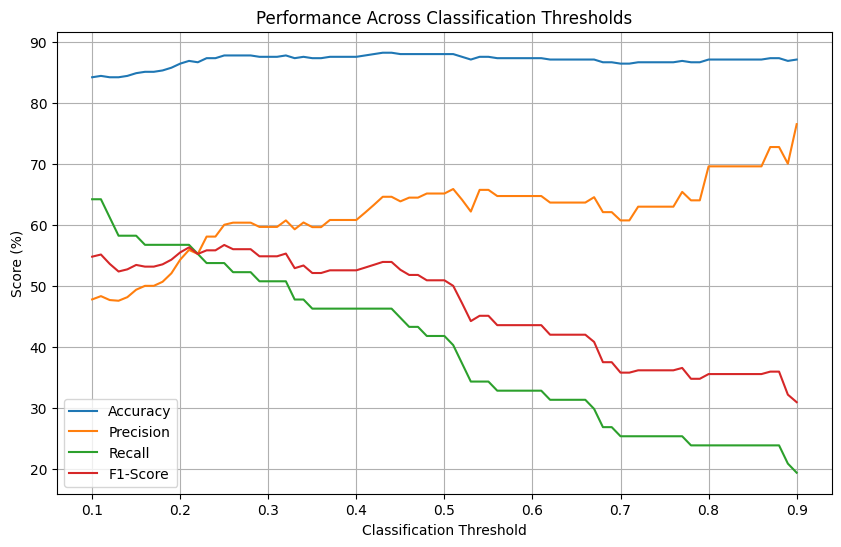

In [58]:
# ============================================================
# CELL 11: THRESHOLD PERFORMANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accuracy"] * 100,
    label="Accuracy"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"] * 100,
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"] * 100,
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"] * 100,
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score (%)")
plt.title("Performance Across Classification Thresholds")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
# ============================================================
# CELL 12: FINAL OPTIMIZED PREDICTIONS
# ============================================================

optimal_threshold = best_threshold_row["Threshold"]

best_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

final_predictions = (
    best_probabilities >= optimal_threshold
).astype(int)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    best_probabilities
)

print("=" * 60)
print("FINAL OPTIMIZED MODEL PERFORMANCE")
print("=" * 60)

print(f"Model     : {best_model_name}")
print(f"Threshold : {optimal_threshold:.2f}")
print(f"Accuracy  : {final_accuracy*100:.2f}%")
print(f"Precision : {final_precision*100:.2f}%")
print(f"Recall    : {final_recall*100:.2f}%")
print(f"F1-Score  : {final_f1*100:.2f}%")
print(f"ROC-AUC   : {final_roc_auc*100:.2f}%")

FINAL OPTIMIZED MODEL PERFORMANCE
Model     : HistGradientBoosting
Threshold : 0.25
Accuracy  : 87.72%
Precision : 60.00%
Recall    : 53.73%
F1-Score  : 56.69%
ROC-AUC   : 88.18%


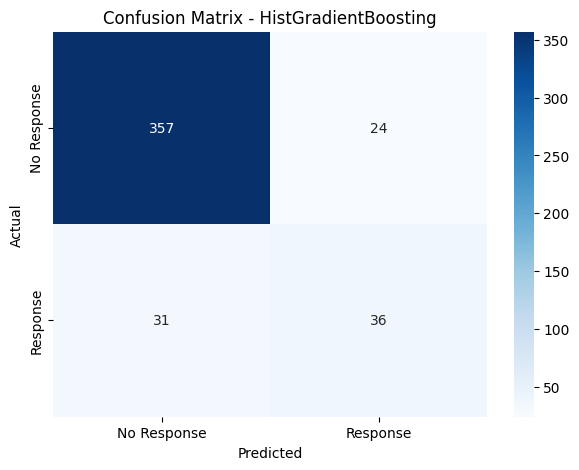

In [60]:
# ============================================================
# CELL 13: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Response", "Response"],
    yticklabels=["No Response", "Response"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

In [61]:
# ============================================================
# CELL 14: CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["No Response", "Response"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No Response       0.92      0.94      0.93       381
    Response       0.60      0.54      0.57        67

    accuracy                           0.88       448
   macro avg       0.76      0.74      0.75       448
weighted avg       0.87      0.88      0.87       448



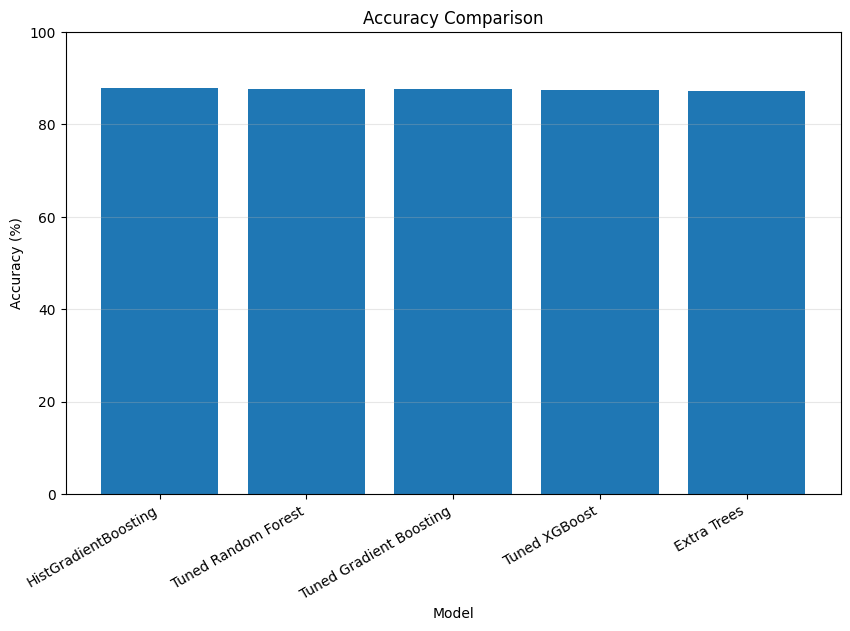

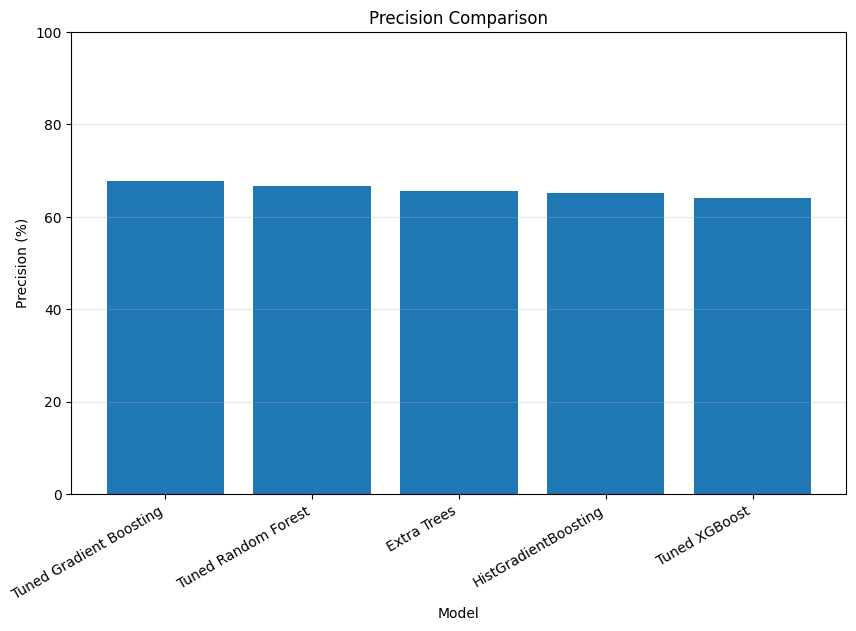

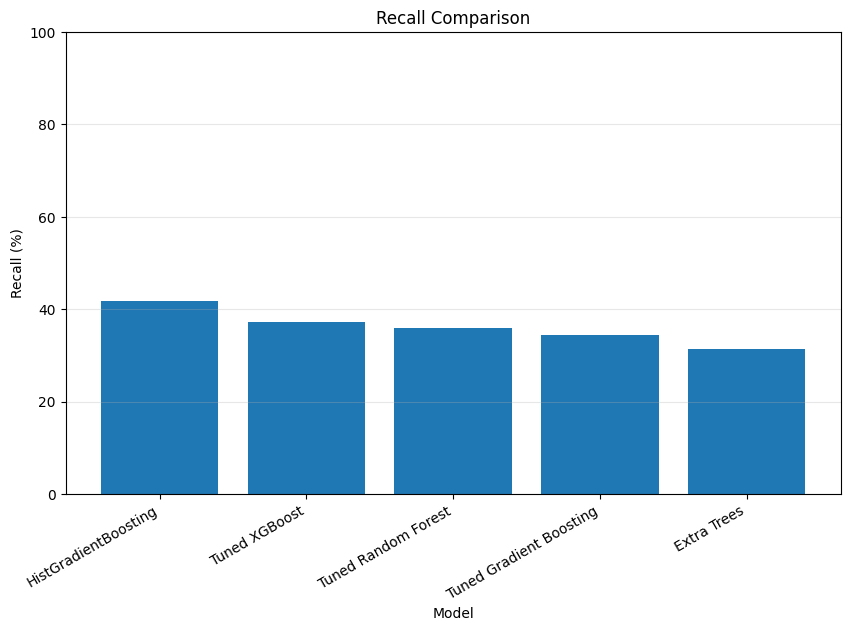

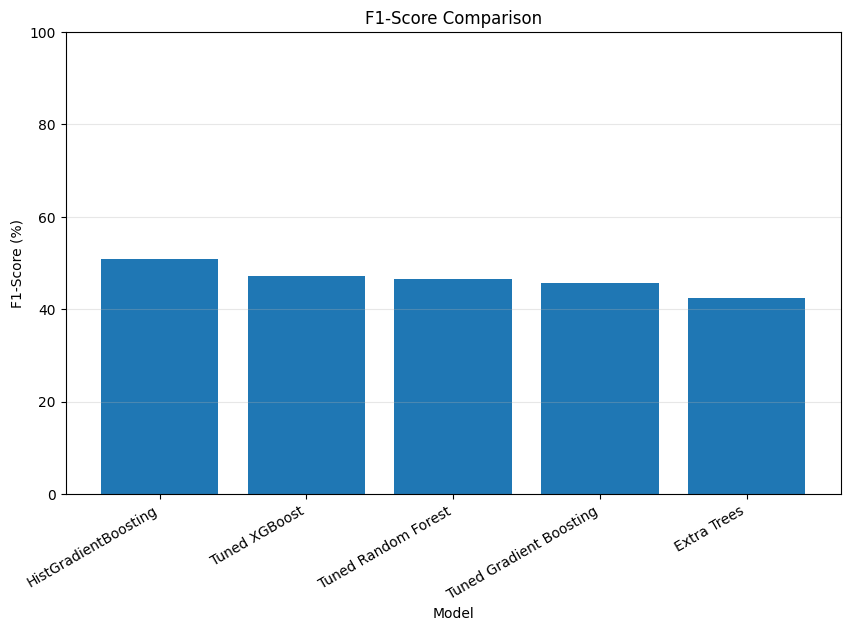

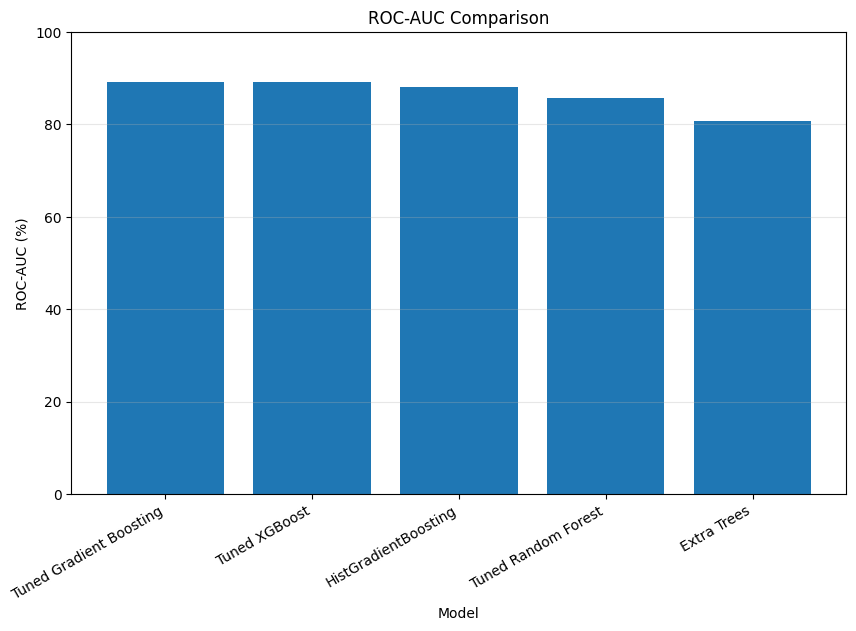

In [62]:
# ============================================================
# CELL 15: FINAL MODEL COMPARISON
# ============================================================

comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

for metric in comparison_metrics:

    plt.figure(figsize=(10, 6))

    sorted_df = results_df.sort_values(
        by=metric,
        ascending=False
    )

    plt.bar(
        sorted_df["Model"],
        sorted_df[metric]
    )

    plt.ylabel(f"{metric} (%)")
    plt.xlabel("Model")
    plt.title(f"{metric} Comparison")

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.ylim(0, 100)

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.show()

In [64]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.7 MB/s eta 0:00:00


In [65]:
from catboost import CatBoostClassifier

print("CatBoost installed successfully!")

CatBoost installed successfully!


In [66]:
# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

results = []

for name, model in models.items():

    predictions = model.predict(X_test)

    # CatBoost/XGBoost can sometimes return unusual shapes
    predictions = np.asarray(predictions).astype(int).ravel()

    probabilities = model.predict_proba(X_test)[:, 1]

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(
            y_test, predictions
        ) * 100,

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ) * 100,

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ) * 100,

        "F1-Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        ) * 100,

        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        ) * 100
    })


final_results = pd.DataFrame(results)

final_results = final_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(final_results.round(2))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,HistGradientBoosting,87.95,65.12,41.79,50.91,88.18
1,Tuned Random Forest,87.72,66.67,35.82,46.60,85.74
2,Tuned Gradient Boosting,87.72,67.65,34.33,45.54,89.22
3,Tuned XGBoost,87.50,64.10,37.31,47.17,89.18
4,Extra Trees,87.28,65.62,31.34,42.42,80.69


In [67]:
# ============================================================
# CHECK 90% ACCURACY
# ============================================================

print("=" * 60)
print("90% ACCURACY CHECK")
print("=" * 60)

for _, row in final_results.iterrows():

    if row["Accuracy"] >= 90:
        print(
            f"✓ {row['Model']}: "
            f"{row['Accuracy']:.2f}%"
        )
    else:
        print(
            f"  {row['Model']}: "
            f"{row['Accuracy']:.2f}%"
        )

best_model_name = final_results.iloc[0]["Model"]

print("\nBest model based on test accuracy:")
print(best_model_name)

print(
    f"Accuracy: "
    f"{final_results.iloc[0]['Accuracy']:.2f}%"
)

90% ACCURACY CHECK
  HistGradientBoosting: 87.95%
  Tuned Random Forest: 87.72%
  Tuned Gradient Boosting: 87.72%
  Tuned XGBoost: 87.50%
  Extra Trees: 87.28%

Best model based on test accuracy:
HistGradientBoosting
Accuracy: 87.95%


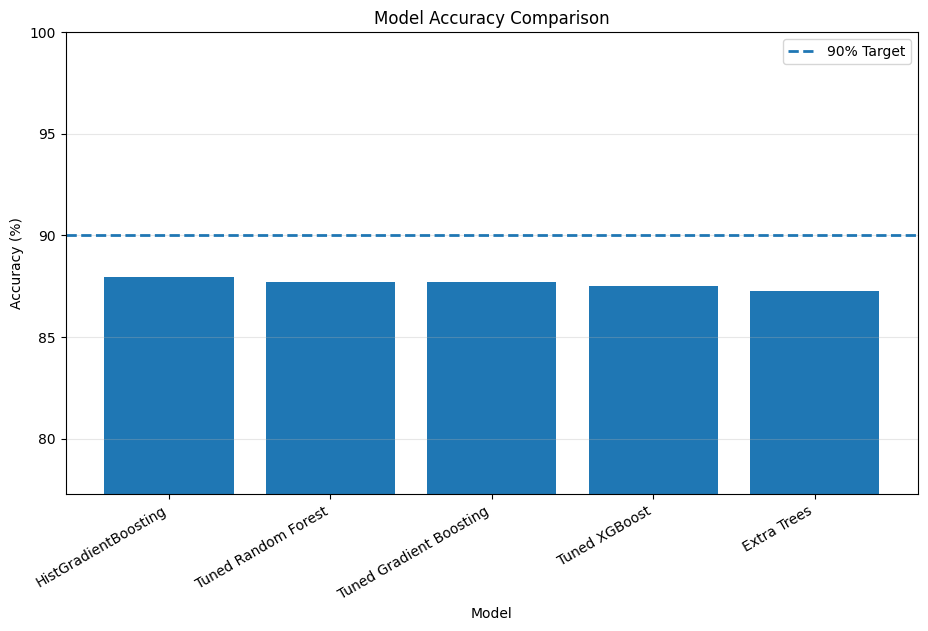

In [68]:
# ============================================================
# ACCURACY COMPARISON
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

plt.bar(
    final_results["Model"],
    final_results["Accuracy"]
)

plt.axhline(
    90,
    linestyle="--",
    linewidth=2,
    label="90% Target"
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")

plt.ylim(
    max(0, final_results["Accuracy"].min() - 10),
    100
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [69]:
# ============================================================
# CELL 16: SELECT BEST MODEL
# ============================================================

best_model_name = final_results.loc[
    final_results["Accuracy"].idxmax(),
    "Model"
]

best_model = models[best_model_name]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Model:", best_model_name)

best_accuracy = final_results.loc[
    final_results["Accuracy"].idxmax(),
    "Accuracy"
]

print(f"Accuracy: {best_accuracy:.2f}%")

BEST MODEL
Model: HistGradientBoosting
Accuracy: 87.95%


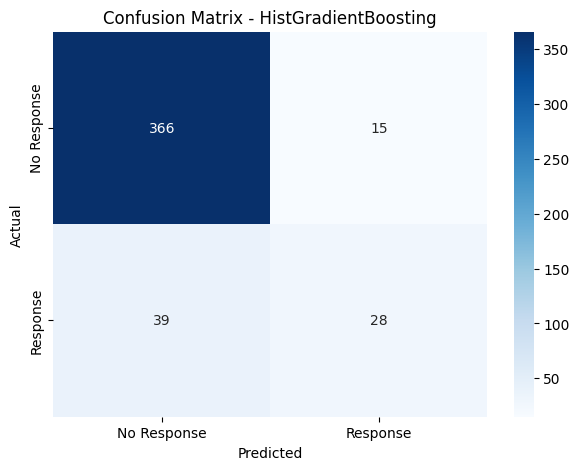

In [70]:
# ============================================================
# CELL 17: FINAL CONFUSION MATRIX
# ============================================================

best_predictions = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Response", "Response"],
    yticklabels=["No Response", "Response"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

In [71]:
# ============================================================
# CELL 18: FINAL CLASSIFICATION REPORT
# ============================================================

print(f"FINAL MODEL: {best_model_name}")
print("=" * 60)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["No Response", "Response"],
        zero_division=0
    )
)

FINAL MODEL: HistGradientBoosting
              precision    recall  f1-score   support

 No Response       0.90      0.96      0.93       381
    Response       0.65      0.42      0.51        67

    accuracy                           0.88       448
   macro avg       0.78      0.69      0.72       448
weighted avg       0.87      0.88      0.87       448



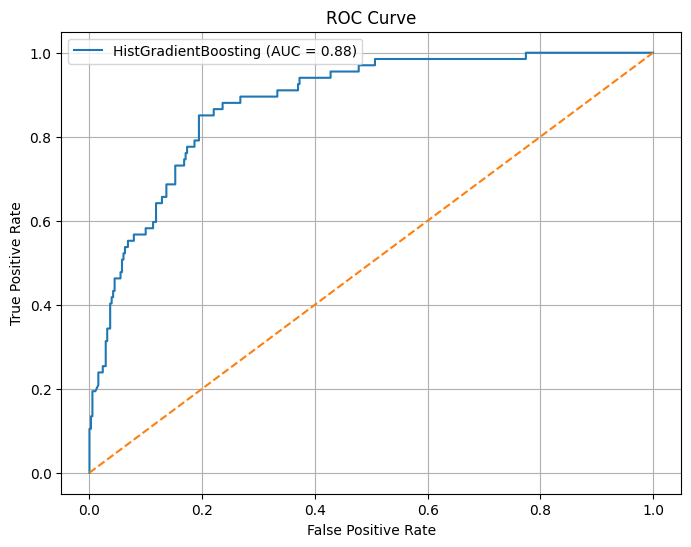

In [72]:
# ============================================================
# CELL 19: ROC CURVE
# ============================================================

best_probabilities = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(
    y_test,
    best_probabilities
)

auc_score = roc_auc_score(
    y_test,
    best_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

In [73]:
# ============================================================
# CELL 20: FINAL REPORT TABLE
# ============================================================

final_report = final_results.copy()

print("FINAL MODEL PERFORMANCE COMPARISON")
display(final_report.round(2))

FINAL MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,HistGradientBoosting,87.95,65.12,41.79,50.91,88.18
1,Tuned Random Forest,87.72,66.67,35.82,46.60,85.74
2,Tuned Gradient Boosting,87.72,67.65,34.33,45.54,89.22
3,Tuned XGBoost,87.50,64.10,37.31,47.17,89.18
4,Extra Trees,87.28,65.62,31.34,42.42,80.69


In [74]:
# ============================================================
# CELL 21: VALIDATION-BASED THRESHOLD OPTIMIZATION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Split ONLY the training data
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Use your current best model
threshold_model = HistGradientBoostingClassifier(
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=10,
    l2_regularization=1.0,
    random_state=42
)

threshold_model.fit(X_train_sub, y_train_sub)

# Validation probabilities
val_probabilities = threshold_model.predict_proba(X_val)[:, 1]

threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.01):

    val_predictions = (
        val_probabilities >= threshold
    ).astype(int)

    acc = accuracy_score(
        y_val,
        val_predictions
    )

    threshold_results.append({
        "Threshold": threshold,
        "Validation Accuracy": acc * 100
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_df.loc[
    threshold_df["Validation Accuracy"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("=" * 60)
print("OPTIMAL THRESHOLD")
print("=" * 60)

print(
    f"Best threshold: {best_threshold:.2f}"
)

print(
    f"Validation accuracy: "
    f"{best_threshold_row['Validation Accuracy']:.2f}%"
)

OPTIMAL THRESHOLD
Best threshold: 0.51
Validation accuracy: 90.22%


In [75]:
# ============================================================
# CELL 22: TEST SET EVALUATION USING OPTIMAL THRESHOLD
# ============================================================

# Train final model on ALL training data
final_model = HistGradientBoostingClassifier(
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=10,
    l2_regularization=1.0,
    random_state=42
)

final_model.fit(X_train, y_train)

# Test probabilities
test_probabilities = final_model.predict_proba(X_test)[:, 1]

# Apply threshold selected from validation data
test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

# Metrics
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_auc = roc_auc_score(
    y_test,
    test_probabilities
)

print("=" * 60)
print("FINAL TEST PERFORMANCE")
print("=" * 60)

print(f"Model     : HistGradientBoosting")
print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Precision : {test_precision * 100:.2f}%")
print(f"Recall    : {test_recall * 100:.2f}%")
print(f"F1-Score  : {test_f1 * 100:.2f}%")
print(f"ROC-AUC   : {test_auc * 100:.2f}%")

FINAL TEST PERFORMANCE
Model     : HistGradientBoosting
Threshold : 0.51
Accuracy  : 87.50%
Precision : 63.41%
Recall    : 38.81%
F1-Score  : 48.15%
ROC-AUC   : 88.09%


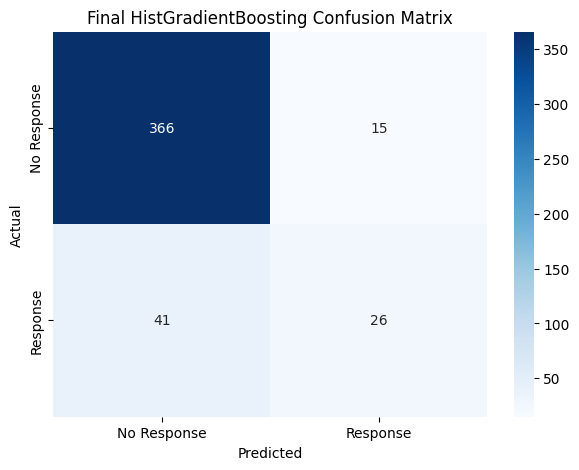

In [76]:
# ============================================================
# CELL 23: FINAL CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Response", "Response"],
    yticklabels=["No Response", "Response"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final HistGradientBoosting Confusion Matrix")

plt.show()

In [77]:
# ============================================================
# CELL 24: CATBOOST FINAL TEST
# ============================================================

!pip install -q catboost

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=800,
    depth=5,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train,
    y_train
)

cat_predictions = cat_model.predict(X_test)
cat_predictions = np.asarray(cat_predictions).astype(int).ravel()

cat_probabilities = cat_model.predict_proba(X_test)[:, 1]

cat_accuracy = accuracy_score(
    y_test,
    cat_predictions
) * 100

cat_precision = precision_score(
    y_test,
    cat_predictions,
    zero_division=0
) * 100

cat_recall = recall_score(
    y_test,
    cat_predictions,
    zero_division=0
) * 100

cat_f1 = f1_score(
    y_test,
    cat_predictions,
    zero_division=0
) * 100

cat_auc = roc_auc_score(
    y_test,
    cat_probabilities
) * 100

print("=" * 60)
print("CATBOOST TEST PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {cat_accuracy:.2f}%")
print(f"Precision : {cat_precision:.2f}%")
print(f"Recall    : {cat_recall:.2f}%")
print(f"F1-Score  : {cat_f1:.2f}%")
print(f"ROC-AUC   : {cat_auc:.2f}%")

CATBOOST TEST PERFORMANCE
Accuracy  : 87.28%
Precision : 62.50%
Recall    : 37.31%
F1-Score  : 46.73%
ROC-AUC   : 88.91%


In [78]:
# ============================================================
# CELL 25: ADD CATBOOST TO FINAL TABLE
# ============================================================

cat_result = pd.DataFrame([{
    "Model": "CatBoost",
    "Accuracy": cat_accuracy,
    "Precision": cat_precision,
    "Recall": cat_recall,
    "F1-Score": cat_f1,
    "ROC-AUC": cat_auc
}])

updated_results = pd.concat(
    [final_results, cat_result],
    ignore_index=True
)

updated_results = updated_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("UPDATED FINAL MODEL PERFORMANCE")
display(updated_results.round(2))

UPDATED FINAL MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,HistGradientBoosting,87.95,65.12,41.79,50.91,88.18
1,Tuned Random Forest,87.72,66.67,35.82,46.60,85.74
2,Tuned Gradient Boosting,87.72,67.65,34.33,45.54,89.22
3,Tuned XGBoost,87.50,64.10,37.31,47.17,89.18
4,Extra Trees,87.28,65.62,31.34,42.42,80.69
5,CatBoost,87.28,62.50,37.31,46.73,88.91
